# Quick Start
## Installation

We assume you have already installed Python and you are familiar with [Jupyter Notebook](https://en.wikipedia.org/wiki/Project_Jupyter#Jupyter_Notebook).

To install the Molass Library package, you can use pip as follows:

```console
pip install -U molass
pip install -U molass_data
```

```{note}
The molass_data package includes a data set for this tutorial.
```

## Tools for Jupyter Notebooks

For programming in Jupyter Notebooks, we recommend either of the following tools (other alternatives are also possible):

* [Jupyter Lab](https://jupyter.org/)
* [Jupyter Extension in VS Code](https://code.visualstudio.com/docs/datascience/jupyter-notebooks)


## Standard Usage
### Plot the Input Data

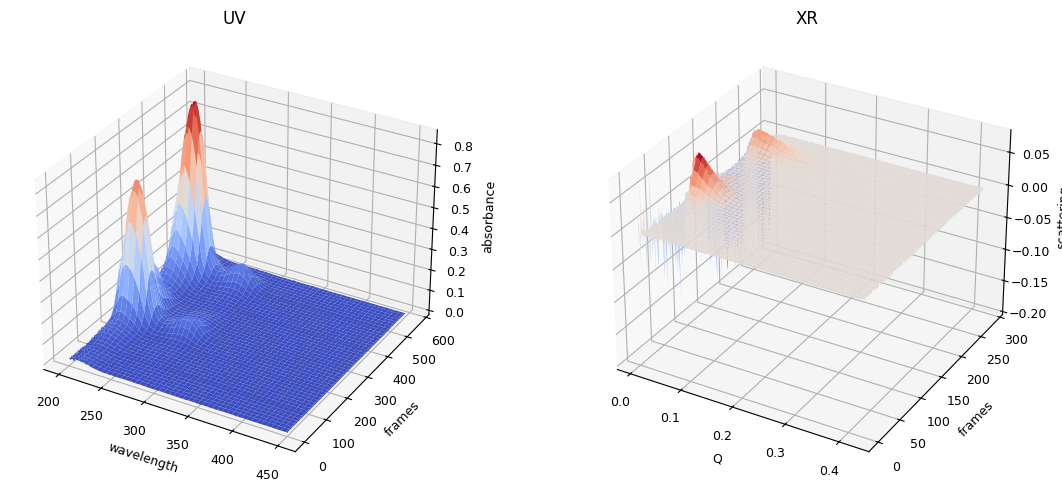

In [1]:
from molass_data import get_tutorial_data_path
from molass.DataObjects import SecSaxsData as SSD
TUTORIAL_DATA = get_tutorial_data_path()
ssd = SSD(TUTORIAL_DATA)
ssd.plot_3d();

### Trimming, Correction and LRF

developper memo: remember that "LowRank.CoupledAdjuster.select_components" is not implemented yet.


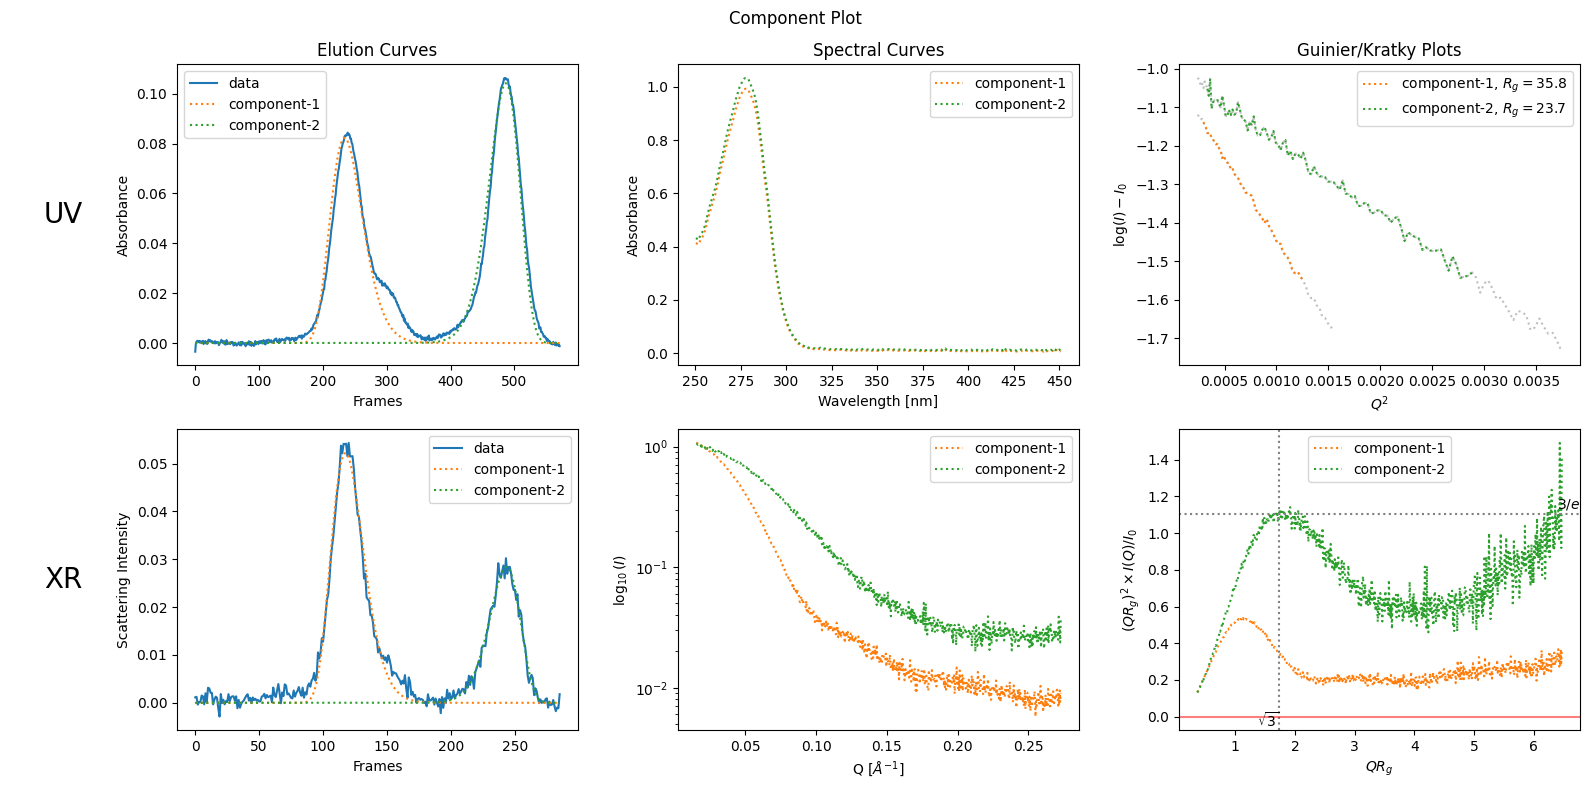

In [2]:
trimmed_ssd = ssd.trimmed_copy()
corrected_ssd = trimmed_ssd.corrected_copy()
lrf_info = corrected_ssd.quick_lowrank_info()
lrf_info.plot_components() 

### Running DENSS

In [3]:
from molass.SAXS.DenssTools import exec_denss
data = lrf_info.get_data_for_denss(k=0)
exec_denss(data)

Dmax = 129.43
Number of experimental Shannon channels: 11
Number of calculated Shannon channels: 33
Scanning alphas... 100% complete
Dmax = 143.72
Number of experimental Shannon channels: 37
Number of calculated Shannon channels: 112

q, I, sigq: 1765 1765 1765
qc, ac, ec: 2766 2766 2766

 Step     Chi2     Rg    Support Volume
 ----- --------- ------- --------------
  620   1.21e-01  75.23        1698782            
switched to shrinkwrap by density threshold = 0.2000
  999   7.49e-05  36.54        421026          EC: 1 -> 1 
 1713   6.70e-05  36.50        358040          

### Plotting the DENSS result

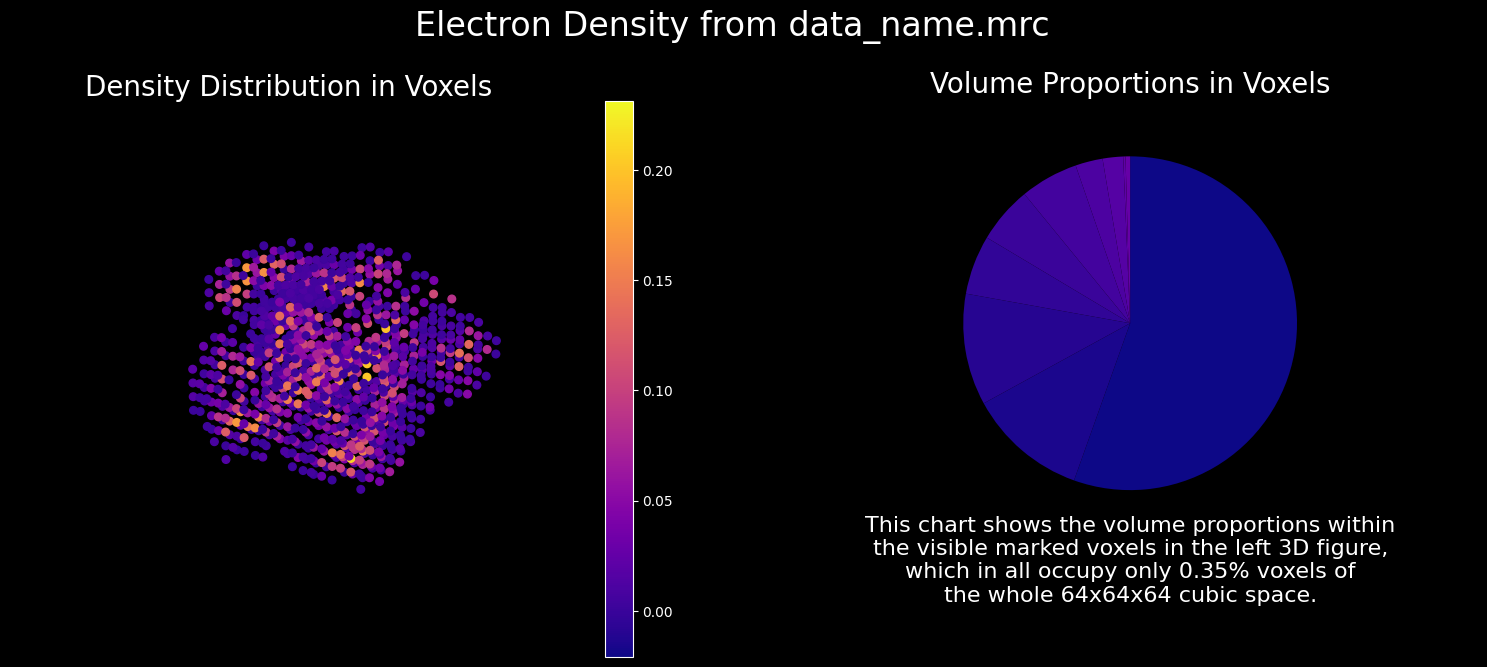

In [4]:
import matplotlib.pyplot as plt
from molass.SAXS.MrcViewer import show_mrc
# %matplotlib widget
%matplotlib inline
show_mrc('data_name.mrc');